In [1]:
import warnings
from collections import Counter
from copy import deepcopy
from dataclasses import dataclass
from itertools import count
from typing import Any

import numpy as np
import pandas as pd
from marsilea import ClusterBoard
from marsilea.layers import LayersMesh, FrameRect, Piece
from marsilea.plotter import Labels, StackBar, Numbers, ColorMesh
from marsilea.utils import get_canvas_size_by_data

from oncoprinter.preset import SHAPE_BANK, MATCH_POOL, Alteration

In [2]:
def guess_alteration(event: str):
    for alt, rule in MATCH_POOL.items():
        if rule.is_match(event):
            return alt
    return Alteration.OTHER

In [3]:
guess_alteration("F:maj")

<Alteration.F_MAJ: 26>

In [23]:
# 假设 MatchRule 类在某处定义
test_cases = [
    ("G:maj something", True),
    ("D:min", True),
    ("random text", False),
]

for alt, rule in MATCH_POOL.items():
    print(f"Testing {alt}")
    for test_input, expected in test_cases:
        if rule.is_match(test_input) != expected:
            print(f"Test failed for input: {test_input}")
        else:
            print(f"Test passed for input: {test_input}")

Testing Alteration.AMP
Test failed for input: G:maj something
Test failed for input: D:min
Test passed for input: random text
Testing Alteration.GAIN
Test failed for input: G:maj something
Test failed for input: D:min
Test passed for input: random text
Testing Alteration.HOMDEL
Test failed for input: G:maj something
Test failed for input: D:min
Test passed for input: random text
Testing Alteration.HETLOSS
Test failed for input: G:maj something
Test failed for input: D:min
Test passed for input: random text
Testing Alteration.MRNA_HIGH
Test failed for input: G:maj something
Test failed for input: D:min
Test passed for input: random text
Testing Alteration.MRNA_LOW
Test failed for input: G:maj something
Test failed for input: D:min
Test passed for input: random text
Testing Alteration.PROTEIN_HIGH
Test failed for input: G:maj something
Test failed for input: D:min
Test passed for input: random text
Testing Alteration.PROTEIN_LOW
Test failed for input: G:maj something
Test failed for inpu

In [8]:
from oncoprinter import OncoPrint
import marsilea as ma
import marsilea.plotter as mp

onco_data = ma.load_data("oncoprint")
cna = onco_data["cna"]
mrna_exp = onco_data["mrna_exp"]
methyl_exp = onco_data["methyl_exp"]
clinical = onco_data["clinical"]
onco_data["cna"]

,sample,track,event
0,TCGA-A8-A097,TP53,Truncating mutation (putative driver)
1,TCGA-A8-A097,TTN,Missense Mutation (putative passenger)
2,TCGA-A8-A097,TP53,sv_rec
3,TCGA-A8-A097,SYNE1,sv
4,TCGA-AR-A256,FLG,Amplification
...,...,...,...
117,TCGA-A2-A0CW,TP53,Truncating mutation (putative driver)
118,TCGA-A2-A0CW,PIK3CA,Missense Mutation (putative driver)
119,TCGA-A2-A0CW,RYR2,Missense Mutation (putative passenger)
120,TCGA-A2-A0CW,USH2A,Missense Mutation (putative passenger)


In [25]:
type(cna['event'][0])

str

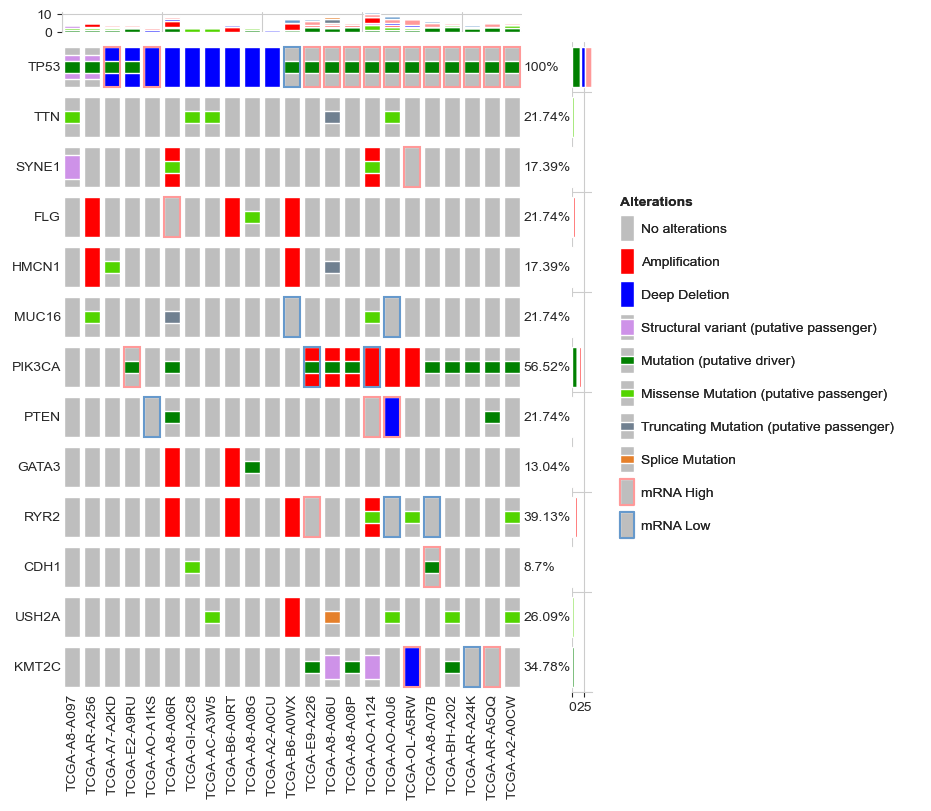

In [11]:
op = OncoPrint(cna, name="main")
op.render()